In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import toolz as tz

from astropy.timeseries import LombScargle
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert, find_peaks

# Cargar datos
data = np.loadtxt("SEMANA.12/T.TAURI.TESS/TIC_264739351.dat")

t = data[:, 0]
f = data[:, 1]

In [3]:
# Quitar media
f = f - np.mean(f)

In [4]:
f_min = 1 / 23    # periodo máximo 
f_max = 1 / 0.1   # periodo mínimo 0.1 días
frequency, power = LombScargle(t, f).autopower(minimum_frequency=f_min,maximum_frequency=f_max,samples_per_peak=10)

In [5]:
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq
print("Periodo dominante:", best_period, "días")

Periodo dominante: 2.2090689280901876 días


Text(0.5, 1.0, 'Estrella')

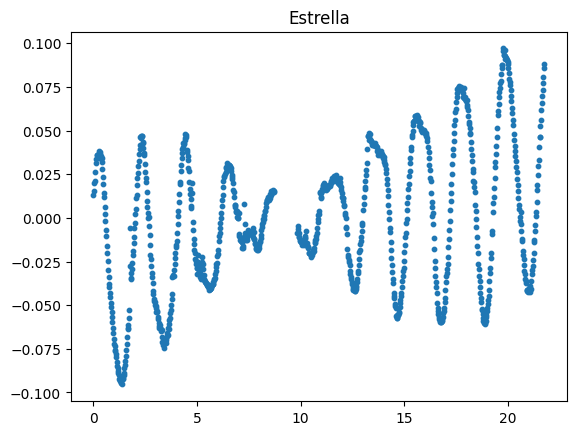

In [6]:
plt.scatter(t, f, s=10)
plt.title("Estrella")

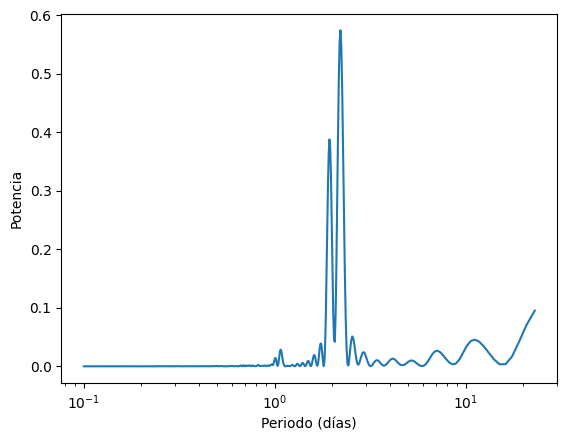

In [7]:
plt.plot(1/frequency, power)
plt.xlabel("Periodo (días)")
plt.ylabel("Potencia")
plt.xscale("log")  # útil para ver mejor
#plt.gca().invert_xaxis()  # opcional (periodos grandes a la derecha)
plt.show()

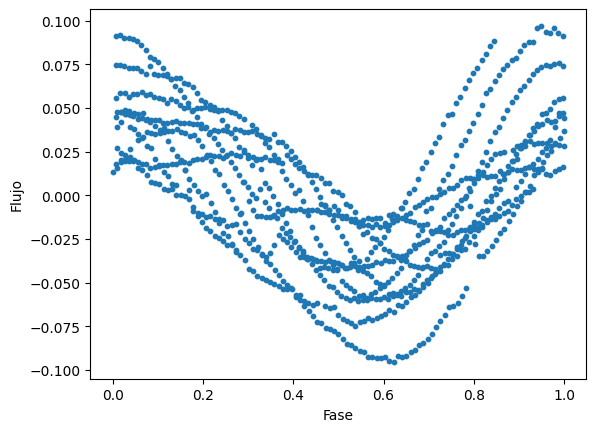

In [8]:
phase = (t % best_period) / best_period
plt.scatter(phase, f, s=10)
plt.xlabel("Fase")
plt.ylabel("Flujo")
plt.show()

In [9]:
# 1. Calcular la envolvente real con Hilbert
analytic_signal = hilbert(f)
envolvente = np.abs(analytic_signal)
# (opcional pero MUY recomendable) suavizar la envolvente
envolvente_suave = gaussian_filter1d(envolvente, sigma=10)
# Modifica la función del modelo para que sea una oscilación 
# sobre un valor medio que mantenga la curva por encima de los datos.
def modelo_envolvente(t, amp, periodo, fase, offset):
    # La envolvente física siempre debe ser > 0 para que tenga sentido 
    # como multiplicador de amplitud.
    return amp * np.sin(2 * np.pi * t / periodo + fase) + offset
# 3. Mejores estimaciones iniciales
guess_amp = 0.5 * (np.max(envolvente_suave) - np.min(envolvente_suave))
guess_offset = np.mean(envolvente_suave)
freq_env, power_env = LombScargle(t, envolvente_suave).autopower(minimum_frequency=1/100,maximum_frequency=1/5,samples_per_peak=20)
guess_period = 1 / freq_env[np.argmax(power_env)]
guess_fase = 0
# 4. Ajuste sobre TODA la envolvente (no solo picos)
popt, pcov = curve_fit(modelo_envolvente,t,envolvente_suave,p0=[guess_amp, guess_period, guess_fase, guess_offset],maxfev=10000)
amp_fit, per_fit, fase_fit, offset_fit = popt
print(f"Periodo de envolvente ajustado: {per_fit:.2f} días")

Periodo de envolvente ajustado: 18.17 días


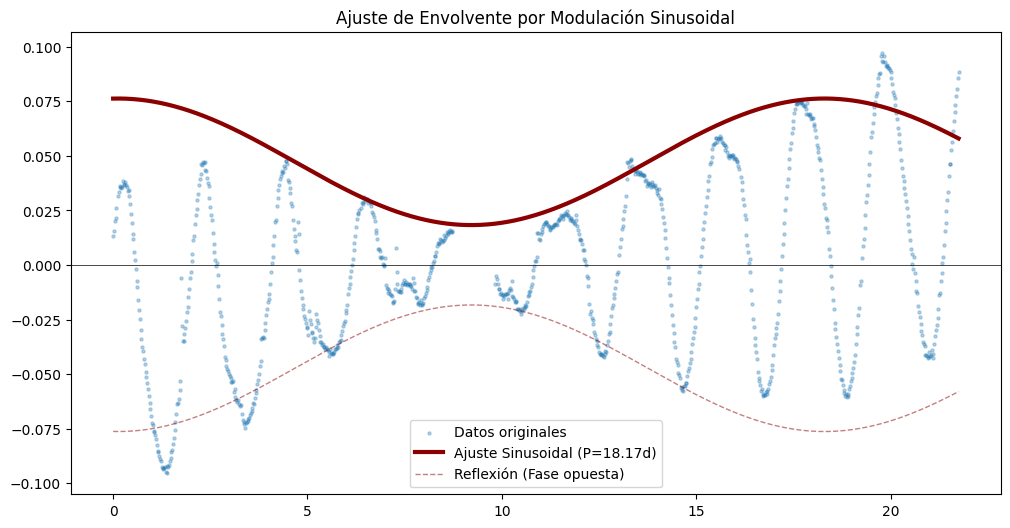

In [10]:
# 4. Visualización
t_plot = np.linspace(t.min(), t.max(), 1000)
env_ajustada = modelo_envolvente(t_plot, *popt)
plt.figure(figsize=(12, 6))
plt.scatter(t, f, s=5, alpha=0.3, label="Datos originales")
plt.plot(t_plot, env_ajustada, color='darkred', lw=3, label=f"Ajuste Sinusoidal (P={per_fit:.2f}d)")
plt.plot(t_plot, -env_ajustada, color='darkred', ls='--', lw=1, alpha=0.5, label="Reflexión (Fase opuesta)")
plt.axhline(0, color='black', lw=0.5)
plt.title("Ajuste de Envolvente por Modulación Sinusoidal")
plt.legend()
plt.show()

In [11]:
import numpy as np

class FourierSeries:
    def __init__(self,n_terms=None,base_freq=None,custom_freqs=None):
        """Represents the b0 + Σₙ [ Aₙ cos(2πfₙt) + Bₙ sin(2πfₙt) ] series. 
        If initialized with only `n_terms`, the `base_freq` is assumed to be 1.0. 
        fₙ = n*base_freq, unless `custom_freqs` is provided, which is used to extract the fₙ.
        If both `custom_freqs` and `n_terms` are specified, the first n elements are used.
        If none are specified, the series will have one term by default.
        """
        self.fitted = False

        if custom_freqs is not None:
            if n_terms is None:
                n_terms = len(custom_freqs)
            self._freqs = np.array(custom_freqs[:n_terms])
        else:
            if n_terms is None:
                n_terms = 1
            if base_freq is None:
                base_freq = 1.0
            self._freqs = np.array([(i+1)*base_freq for i in range(n_terms)])
        self.n_terms = n_terms
        self._raw_coef = np.zeros(1+2*n_terms)
        self._param_names = ["base"] + list(tz.interleave((
            [f"A_{i+1}" for i in range(n_terms)],
            [f"B_{i+1}" for i in range(n_terms)]
        )))
    
    def __repr__(self):
        return f"<FourierSeries with {self.n_terms} terms>\nfitted: {self.fitted}\nparameters:\n" + self.parameters.to_string()
    
    def _design_matrix(self,ts):
        ts = np.array(ts)
        N = len(ts)
        const = np.ones(N)
        SIN = np.sin(2*np.pi*self._freqs[:,None]*ts[None,:])
        COS = np.cos(2*np.pi*self._freqs[:,None]*ts[None,:])
        return np.vstack([const] + list(tz.interleave([SIN,COS]))).T
        
    def __call__(self,t):
        scalar = np.isscalar(t)
        T = np.atleast_1d(t)
        X = self._design_matrix(T)
        return X @ self._raw_coef
    
    @property
    def parameters(self):
        return pd.Series(self._raw_coef,index=self._param_names)

    @property
    def A_n(self):
        return self._raw_coef[1::2]

    @property
    def B_n(self):
        return self._raw_coef[2::2]
        
        
    def fit(self,xdata,ydata,weights=None):
        """Performs OLS fit on the given data, which must be free of NaNs and infinite values.
        This instance is given the fitted parameters and the covariance matrix
        """
        X = self._design_matrix(xdata)
        self._raw_coef = np.linalg.pinv(X) @ ydata
        response = X @ self._raw_coef
        self.fitted = True
        return ydata - response

Periodo inicial: 17.8642706250722
base    0.046476
A_1     0.002798
B_1     0.028717
A_2     0.002995
B_2    -0.001446
A_3     0.002295
B_3     0.001724
dtype: float64


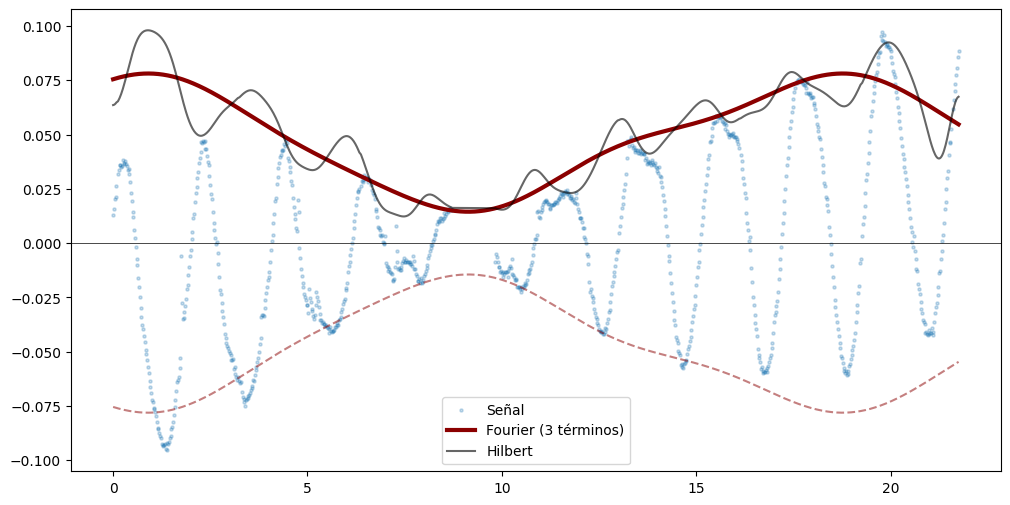

RMS residual: 0.00976215818404787


In [12]:
# -------------------------
# señal centrada
# -------------------------
y = f - np.mean(f)

# -------------------------
# amplitud instantánea
# -------------------------
env = np.abs(hilbert(y))

# suavizado moderado
env = gaussian_filter1d(env, sigma=10)

# -------------------------
# frecuencia dominante
# -------------------------
freq_env, power_env = LombScargle(
    t,
    env
).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)

f0 = freq_env[np.argmax(power_env)]
P0 = 1/f0

print("Periodo inicial:", P0)

# -------------------------
# Fourier armónico
# -------------------------
N = 3

fs = FourierSeries(
    n_terms=N,
    base_freq=f0
)

res = fs.fit(
    t,
    env
)

print(fs.parameters)

# -------------------------
# evaluar
# -------------------------
tt = np.linspace(
    t.min(),
    t.max(),
    3000
)

env_fit = fs(tt)

# -------------------------
# graficar
# -------------------------
plt.figure(figsize=(12,6))

plt.scatter(
    t,
    y,
    s=5,
    alpha=0.25,
    label="Señal"
)

plt.plot(
    tt,
    env_fit,
    lw=3,
    color="darkred",
    label=f"Fourier ({N} términos)"
)

plt.plot(
    tt,
    -env_fit,
    "--",
    color="darkred",
    alpha=0.5
)

plt.plot(
    t,
    env,
    color="black",
    alpha=0.6,
    label="Hilbert"
)

plt.axhline(
    0,
    color="k",
    lw=0.5
)

plt.legend()
plt.show()

print("RMS residual:", np.std(res))

Periodo RMS: 18.031479066532263


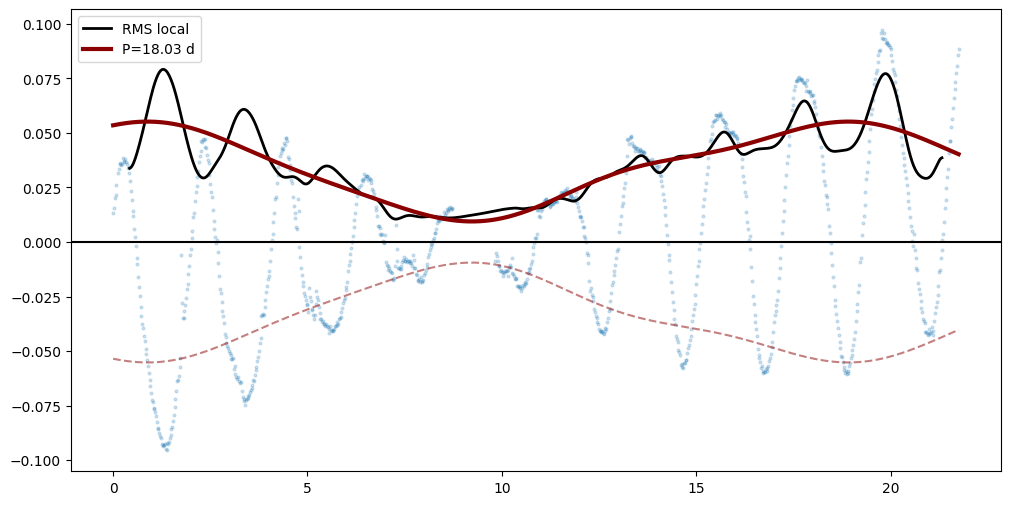

In [13]:
# -------------------------
# señal centrada
# -------------------------
y = f - np.mean(f)

# -------------------------
# RMS móvil
# -------------------------
window = 40

amp = []
t_amp = []

for i in range(len(y)-window):

    amp.append(
        np.sqrt(
            np.mean(
                y[i:i+window]**2
            )
        )
    )

    t_amp.append(
        np.mean(
            t[i:i+window]
        )
    )

amp = np.array(amp)
t_amp = np.array(t_amp)

# suavizar
amp = gaussian_filter1d(
    amp,
    sigma=5
)

# -------------------------
# buscar frecuencia
# -------------------------
freq_amp, power_amp = LombScargle(
    t_amp,
    amp
).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)

f_env = freq_amp[
    np.argmax(power_amp)
]

P_env = 1/f_env

print("Periodo RMS:", P_env)

# -------------------------
# Fourier RMS
# -------------------------
fs_amp = FourierSeries(
    n_terms=3,
    base_freq=f_env
)

fs_amp.fit(
    t_amp,
    amp
)

tt = np.linspace(
    t.min(),
    t.max(),
    3000
)

env_fit = fs_amp(tt)

# -------------------------
# visualizar
# -------------------------
plt.figure(figsize=(12,6))

plt.scatter(
    t,
    y,
    s=4,
    alpha=0.2
)

plt.plot(
    t_amp,
    amp,
    lw=2,
    color="black",
    label="RMS local"
)

plt.plot(
    tt,
    env_fit,
    color="darkred",
    lw=3,
    label=f"P={P_env:.2f} d"
)

plt.plot(
    tt,
    -env_fit,
    "--",
    color="darkred",
    alpha=0.5
)

plt.axhline(
    0,
    color="k"
)

plt.legend()
plt.show()

Periodo envolvente: 18.031479066532263


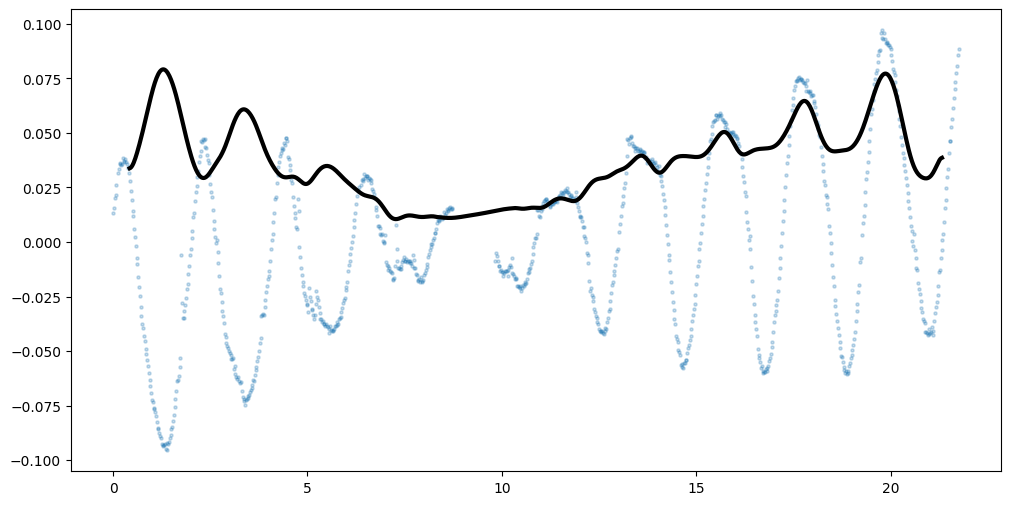

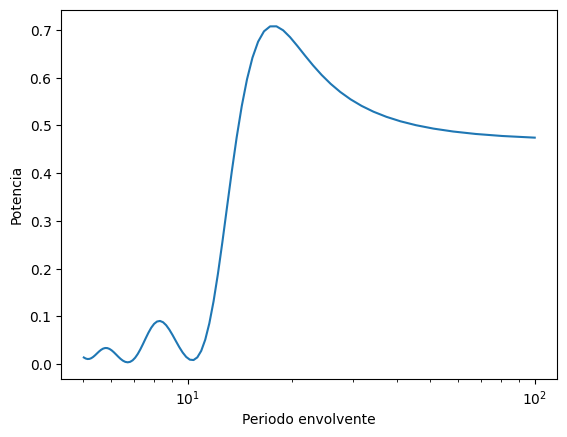

In [14]:
import numpy as np
from astropy.timeseries import LombScargle
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


def periodo_envolvente_rms(
    t,
    y,
    window=40,
    sigma=5,
    pmin=5,
    pmax=100
):

    y = y - np.mean(y)

    amp = []
    tc = []

    for i in range(len(y)-window):

        amp.append(
            np.sqrt(
                np.mean(
                    y[i:i+window]**2
                )
            )
        )

        tc.append(
            np.mean(
                t[i:i+window]
            )
        )

    amp = np.array(amp)
    tc = np.array(tc)

    amp = gaussian_filter1d(
        amp,
        sigma=sigma
    )

    freq, power = LombScargle(
        tc,
        amp
    ).autopower(
        minimum_frequency=1/pmax,
        maximum_frequency=1/pmin,
        samples_per_peak=20
    )

    idx = np.argmax(power)

    return {
        "P_env":1/freq[idx],
        "Power":power[idx],
        "RMS_curve":amp,
        "t_rms":tc,
        "freq":freq,
        "power":power
    }


res = periodo_envolvente_rms(
    t,
    f
)

print(
    "Periodo envolvente:",
    res["P_env"]
)

plt.figure(figsize=(12,6))

plt.scatter(
    t,
    f,
    s=5,
    alpha=0.25
)

plt.plot(
    res["t_rms"],
    res["RMS_curve"],
    lw=3,
    color="black"
)

plt.show()


plt.figure()

plt.plot(
    1/res["freq"],
    res["power"]
)

plt.xscale("log")

plt.xlabel(
    "Periodo envolvente"
)

plt.ylabel(
    "Potencia"
)

plt.show()

Se intentaron varios métodos, pero ninguno parece tener una respuesta significativamente diferente de lo inicial, entonces se va a intentar ajustar mucho mejor a la estrella, con la idea del cruce.


[Idea 1 corregida] P_env = 100.00 días


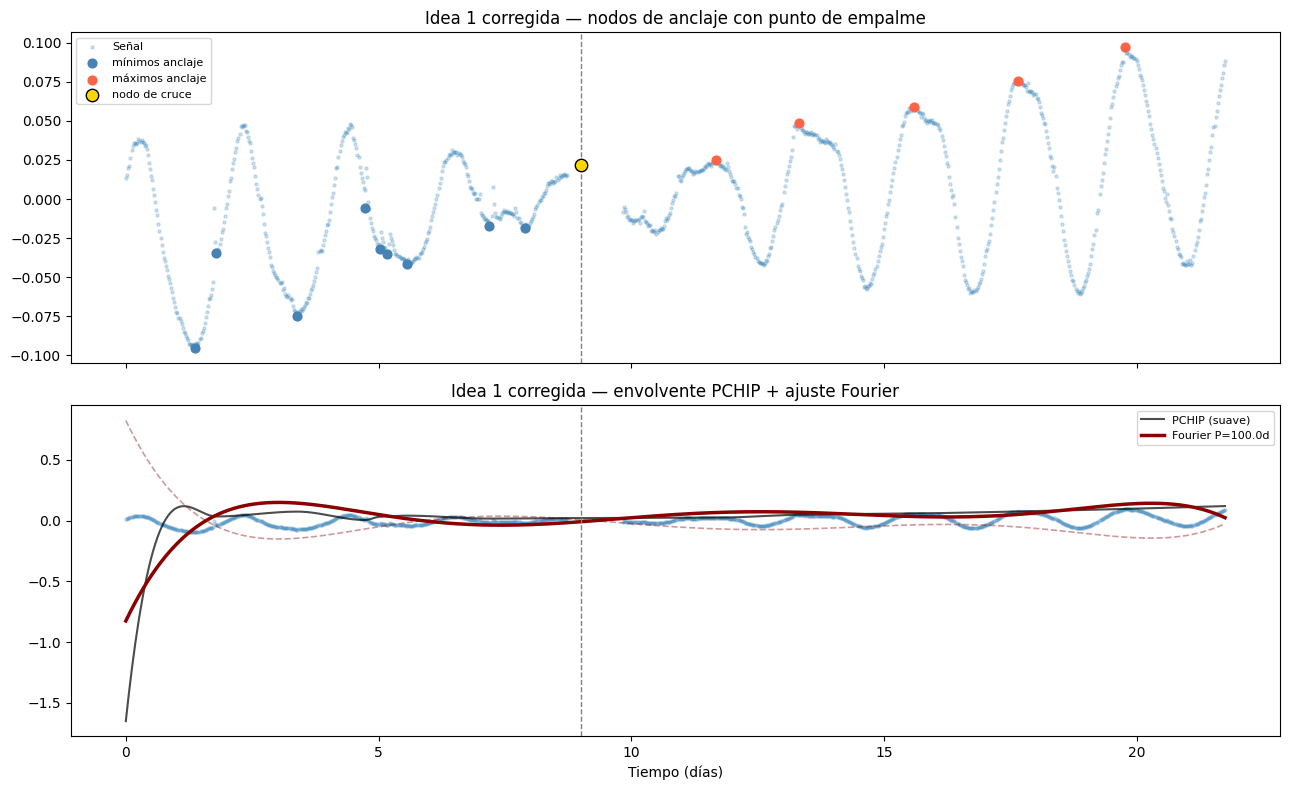

In [15]:
from scipy.interpolate import PchipInterpolator

T_CRUCE = 9.0
sigma   = 10
y = f - np.mean(f)

mask_iz = t < T_CRUCE
mask_de = t >= T_CRUCE

# ══════════════════════════════════════════════
# IDEA 1 CORREGIDA — empalme suave con PCHIP
# ══════════════════════════════════════════════

# ── izquierda: picos negativos (mínimos) ──
y_iz = y[mask_iz]
t_iz = t[mask_iz]

picos_min, _ = find_peaks(-y_iz, prominence=0.01, distance=5)

if len(picos_min) >= 3:
    t_anc_iz  = t_iz[picos_min]
    v_anc_iz  = np.abs(y_iz[picos_min])
else:
    # fallback: RMS local
    amp_iz = gaussian_filter1d(np.abs(hilbert(y_iz)), sigma=min(sigma, len(y_iz)//4))
    t_anc_iz = t_iz
    v_anc_iz = amp_iz

# ── derecha: picos positivos (máximos) ──
y_de = y[mask_de]
t_de = t[mask_de]

picos_max, _ = find_peaks(y_de, prominence=0.01, distance=5)

if len(picos_max) >= 3:
    t_anc_de  = t_de[picos_max]
    v_anc_de  = y_de[picos_max]
else:
    amp_de = gaussian_filter1d(np.abs(hilbert(y_de)), sigma=min(sigma, len(y_de)//4))
    t_anc_de = t_de
    v_anc_de = amp_de

# ── valor en el cruce: media de los dos lados para forzar continuidad ──
val_cruce_iz = float(np.interp(T_CRUCE, t_anc_iz, v_anc_iz))
val_cruce_de = float(np.interp(T_CRUCE, t_anc_de, v_anc_de))
val_cruce    = 0.5 * (val_cruce_iz + val_cruce_de)

# Añadimos el punto de cruce a AMBOS lados
t_nodos = np.concatenate([t_anc_iz, [T_CRUCE], t_anc_de])
v_nodos = np.concatenate([v_anc_iz, [val_cruce], v_anc_de])

# Ordenar por t (por si hay duplicados cerca del cruce)
orden   = np.argsort(t_nodos)
t_nodos = t_nodos[orden]
v_nodos = v_nodos[orden]

# ── interpolación PCHIP: monotónica, sin oscilaciones de Runge ──
interp  = PchipInterpolator(t_nodos, v_nodos)
env_1c  = interp(t)          # envolvente suave sobre todo t

# ── Lomb-Scargle + Fourier sobre la envolvente suave ──
freq1c, pow1c = LombScargle(t, env_1c).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)
P_env1c = 1 / freq1c[np.argmax(pow1c)]
print(f"[Idea 1 corregida] P_env = {P_env1c:.2f} días")

fs1c = FourierSeries(n_terms=3, base_freq=1/P_env1c)
fs1c.fit(t, env_1c)

tt = np.linspace(t.min(), t.max(), 3000)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.scatter(t, y, s=5, alpha=0.2, label="Señal")
ax.scatter(t_anc_iz, -v_anc_iz, s=40, color="steelblue", zorder=5, label="mínimos anclaje")
ax.scatter(t_anc_de,  v_anc_de, s=40, color="tomato",    zorder=5, label="máximos anclaje")
ax.scatter([T_CRUCE], [val_cruce], s=80, color="gold",
           edgecolors="k", zorder=6, label="nodo de cruce")
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_title("Idea 1 corregida — nodos de anclaje con punto de empalme")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(t, y, s=5, alpha=0.2)
ax.plot(t, env_1c,     color="k",       lw=1.5, alpha=0.7, label="PCHIP (suave)")
ax.plot(tt, fs1c(tt),  color="darkred", lw=2.5, label=f"Fourier P={P_env1c:.1f}d")
ax.plot(tt, -fs1c(tt), color="darkred", lw=1.2, ls="--", alpha=0.4)
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_xlabel("Tiempo (días)")
ax.set_title("Idea 1 corregida — envolvente PCHIP + ajuste Fourier")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

[Idea 2 corregida] P_env = 17.16 días


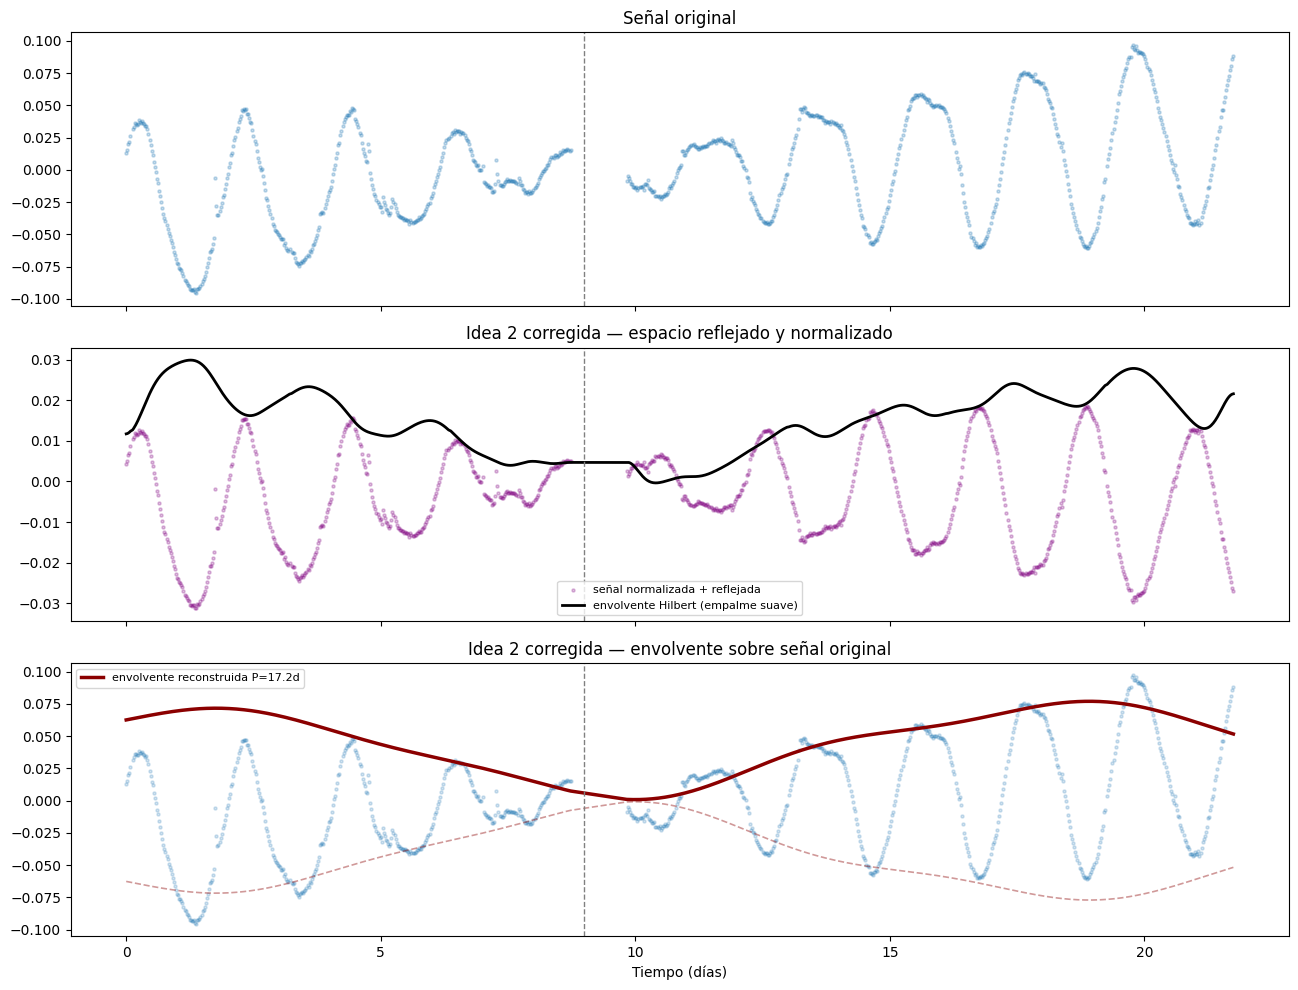


Resumen corregido:
  Idea 1 — P_env = 100.00 días  (PCHIP + nodo de cruce)
  Idea 2 — P_env = 17.16 días  (normalización + empalme exponencial)


In [16]:

y_iz     = y[mask_iz]
t_iz     = t[mask_iz]
y_de     = y[mask_de]
t_de     = t[mask_de]

# Escala de la izquierda: amplitud RMS local cerca del cruce (ventana 2d)
ventana_cruce = (t >= T_CRUCE - 2) & (t <= T_CRUCE + 2)
amp_cruce = np.sqrt(np.mean(y[ventana_cruce]**2)) if ventana_cruce.sum() > 0 else 1.0

# Normalizamos cada mitad a su propia amplitud, luego re-escalamos a amp_cruce
# Esto elimina el salto vertical en t=10
amp_iz_rms = np.sqrt(np.mean(y_iz**2)) or 1.0
amp_de_rms = np.sqrt(np.mean(y_de**2)) or 1.0

y_iz_norm     =  y_iz / amp_iz_rms * amp_cruce
y_de_flip_norm = -y_de / amp_de_rms * amp_cruce   # reflejo + normalización

# Concatenar
t_flip2 = np.concatenate([t_iz,        t_de])
y_flip2 = np.concatenate([y_iz_norm, y_de_flip_norm])

# Envolvente Hilbert por mitad (evita artefactos de borde al concatenar)
env2_iz = gaussian_filter1d(np.abs(hilbert(y_iz_norm)),      sigma=min(sigma, len(y_iz)//4))
env2_de = gaussian_filter1d(np.abs(hilbert(y_de_flip_norm)), sigma=min(sigma, len(y_de)//4))

# Empalme suave: ajustamos el nivel de la segunda mitad al final de la primera
delta = env2_iz[-1] - env2_de[0]
env2_de_adj = env2_de + delta * np.exp(-np.linspace(0, 5, len(env2_de)))  # decay exponencial
env2_2c = np.concatenate([env2_iz, env2_de_adj])

# Periodo
freq2c, pow2c = LombScargle(t_flip2, env2_2c).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)
P_env2c = 1 / freq2c[np.argmax(pow2c)]
print(f"[Idea 2 corregida] P_env = {P_env2c:.2f} días")

fs2c = FourierSeries(n_terms=3, base_freq=1/P_env2c)
fs2c.fit(t_flip2, env2_2c)

# ── Reconstrucción en espacio original ──
# La envolvente en t<10 vale directamente fs2c(t)*amp_iz_rms/amp_cruce
# En t>=10 hay que deshacer el reflejo: vuelve a ser positiva con escala original
env_rec = np.empty(len(t))
env_rec[mask_iz] =  fs2c(t[mask_iz]) * amp_iz_rms / amp_cruce
env_rec[mask_de] =  np.abs(fs2c(t[mask_de])) * amp_de_rms / amp_cruce

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.scatter(t, y, s=5, alpha=0.25)
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_title("Señal original")

ax = axes[1]
ax.scatter(t_flip2, y_flip2, s=5, alpha=0.25, color="purple", label="señal normalizada + reflejada")
ax.plot(t_flip2, env2_2c, color="k", lw=2, label="envolvente Hilbert (empalme suave)")
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_title("Idea 2 corregida — espacio reflejado y normalizado")
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(t, y, s=5, alpha=0.2)
ax.plot(t, env_rec,   color="darkred", lw=2.5, label=f"envolvente reconstruida P={P_env2c:.1f}d")
ax.plot(t, -env_rec,  color="darkred", lw=1.2, ls="--", alpha=0.4)
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_xlabel("Tiempo (días)")
ax.set_title("Idea 2 corregida — envolvente sobre señal original")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nResumen corregido:")
print(f"  Idea 1 — P_env = {P_env1c:.2f} días  (PCHIP + nodo de cruce)")
print(f"  Idea 2 — P_env = {P_env2c:.2f} días  (normalización + empalme exponencial)")

[Idea 3] P_env = 21.38 días


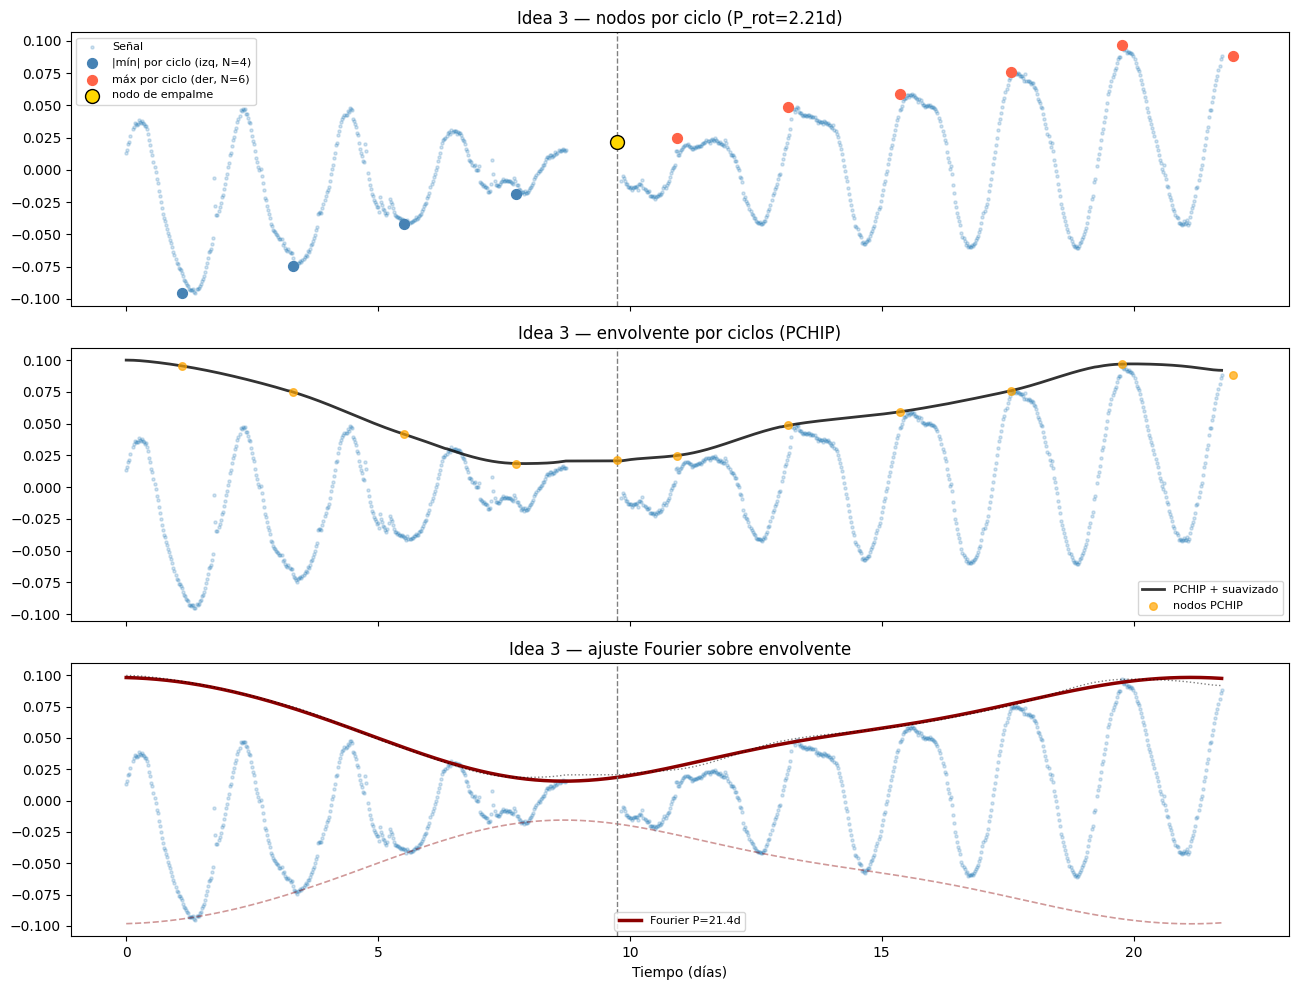

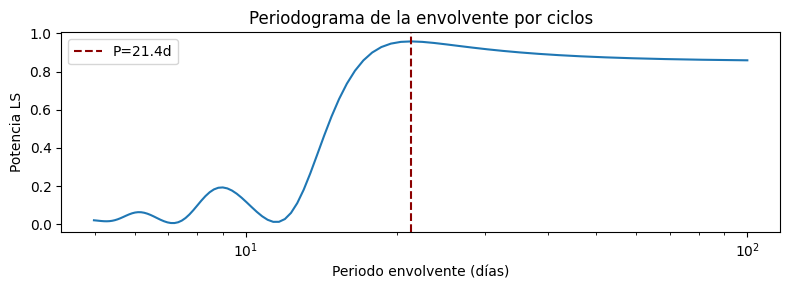

In [17]:
from scipy.interpolate import PchipInterpolator

T_CRUCE  = 9.75
P_rot    = best_period   # el periodo dominante ya calculado (~1.5d)
sigma    = 15
y = f - np.mean(f)

# ══════════════════════════════════════════════════════════
# UTILIDAD: envolvente por máximos de ciclo (fold-based)
# Evita find_peaks sobre la señal cruda.
# ══════════════════════════════════════════════════════════

def envolvente_por_ciclos(t, y, P, sigma=15, modo="max"):
    """
    Divide la serie en ventanas de ancho P (un ciclo de rotación).
    En cada ventana toma el máximo (modo='max') o |mínimo| (modo='min')
    como estimado de la amplitud local.
    Devuelve (t_cent, amp) — un punto por ciclo.
    """
    t0, t1 = t.min(), t.max()
    bordes  = np.arange(t0, t1 + P, P)
    t_cent, amp = [], []

    for i in range(len(bordes) - 1):
        mask = (t >= bordes[i]) & (t < bordes[i+1])
        if mask.sum() < 3:
            continue
        yi = y[mask]
        t_cent.append(0.5 * (bordes[i] + bordes[i+1]))
        if modo == "max":
            amp.append(np.max(yi))
        elif modo == "min":
            amp.append(np.abs(np.min(yi)))
        else:  # "rms"
            amp.append(np.sqrt(np.mean(yi**2)) * np.sqrt(2))

    t_cent = np.array(t_cent)
    amp    = np.array(amp)

    # suavizado ligero (solo para quitar ruido de muestreo, no de física)
    if sigma > 0 and len(amp) > 2*sigma:
        amp = gaussian_filter1d(amp, sigma=sigma/P)

    return t_cent, amp


# ══════════════════════════════════════════════════════════
# IDEA 3 — envolvente híbrida por ciclos, empalme PCHIP
# ══════════════════════════════════════════════════════════

mask_iz = t < T_CRUCE
mask_de = t >= T_CRUCE

# Izquierda: tomamos |mínimos| de cada ciclo
t_iz_c, amp_iz_c = envolvente_por_ciclos(
    t[mask_iz], y[mask_iz], P_rot, sigma=sigma, modo="min"
)

# Derecha: tomamos máximos de cada ciclo
t_de_c, amp_de_c = envolvente_por_ciclos(
    t[mask_de], y[mask_de], P_rot, sigma=sigma, modo="max"
)

# ── nodo de cruce: promedio de los valores al borde ──
val_cruce = 0.5 * (
    float(np.interp(T_CRUCE, t_iz_c, amp_iz_c)) +
    float(np.interp(T_CRUCE, t_de_c, amp_de_c))
)

t_nodos = np.concatenate([t_iz_c, [T_CRUCE], t_de_c])
v_nodos = np.concatenate([amp_iz_c, [val_cruce], amp_de_c])

orden   = np.argsort(t_nodos)
t_nodos = t_nodos[orden]
v_nodos = v_nodos[orden]

interp3 = PchipInterpolator(t_nodos, v_nodos)
env3    = interp3(t)

# ── opcional: un pase gaussiano final suaviza sin distorsionar ──
env3_suave = gaussian_filter1d(env3, sigma=10)

# ── Lomb-Scargle sobre la envolvente ──
freq3, pow3 = LombScargle(t, env3_suave).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)
P_env3 = 1 / freq3[np.argmax(pow3)]
print(f"[Idea 3] P_env = {P_env3:.2f} días")

# ── Fourier sobre la envolvente ──
fs3 = FourierSeries(n_terms=3, base_freq=1/P_env3)
fs3.fit(t, env3_suave)

tt = np.linspace(t.min(), t.max(), 3000)

# ── diagnóstico: ver cuántos ciclos hay y dónde caen los nodos ──
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.scatter(t, y, s=5, alpha=0.2, label="Señal")
ax.scatter(t_iz_c, -amp_iz_c, s=50, color="steelblue",
           zorder=5, label=f"|mín| por ciclo (izq, N={len(t_iz_c)})")
ax.scatter(t_de_c,  amp_de_c, s=50, color="tomato",
           zorder=5, label=f"máx por ciclo (der, N={len(t_de_c)})")
ax.scatter([T_CRUCE], [val_cruce], s=100, color="gold",
           edgecolors="k", zorder=6, label="nodo de empalme")
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_title(f"Idea 3 — nodos por ciclo (P_rot={P_rot:.2f}d)")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(t, y, s=5, alpha=0.2)
ax.plot(t, env3_suave, color="k", lw=2, alpha=0.8, label="PCHIP + suavizado")
ax.scatter(t_nodos, v_nodos, s=30, color="orange",
           zorder=5, alpha=0.7, label="nodos PCHIP")
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_title("Idea 3 — envolvente por ciclos (PCHIP)")
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(t, y, s=5, alpha=0.2)
ax.plot(tt,  fs3(tt), color="darkred", lw=2.5,
        label=f"Fourier P={P_env3:.1f}d")
ax.plot(tt, -fs3(tt), color="darkred", lw=1.2, ls="--", alpha=0.4)
ax.plot(t,  env3_suave, color="k", lw=1, alpha=0.5, ls=":")
ax.axvline(T_CRUCE, color="gray", lw=1, ls="--")
ax.set_xlabel("Tiempo (días)")
ax.set_title("Idea 3 — ajuste Fourier sobre envolvente")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── periodograma de la envolvente (diagnóstico) ──
plt.figure(figsize=(8, 3))
plt.plot(1/freq3, pow3)
plt.xscale("log")
plt.xlabel("Periodo envolvente (días)")
plt.ylabel("Potencia LS")
plt.title("Periodograma de la envolvente por ciclos")
plt.axvline(P_env3, color="darkred", lw=1.5, ls="--",
            label=f"P={P_env3:.1f}d")
plt.legend()
plt.tight_layout()
plt.show()

La lógica central del cambio: en vez de pedirle a find_peaks que encuentre mínimos en una señal con ruido y amplitud variable, dividimos el tiempo en ventanas de exactamente un periodo de rotación. En cada ventana hay exactamente un ciclo completo, así que el np.max o np.abs(np.min) da el valor de amplitud de ese ciclo sin ambigüedad. Con ~15 ciclos en 22 días tendrás ~15 nodos limpios para el PCHIP, que es suficiente para ver la modulación.

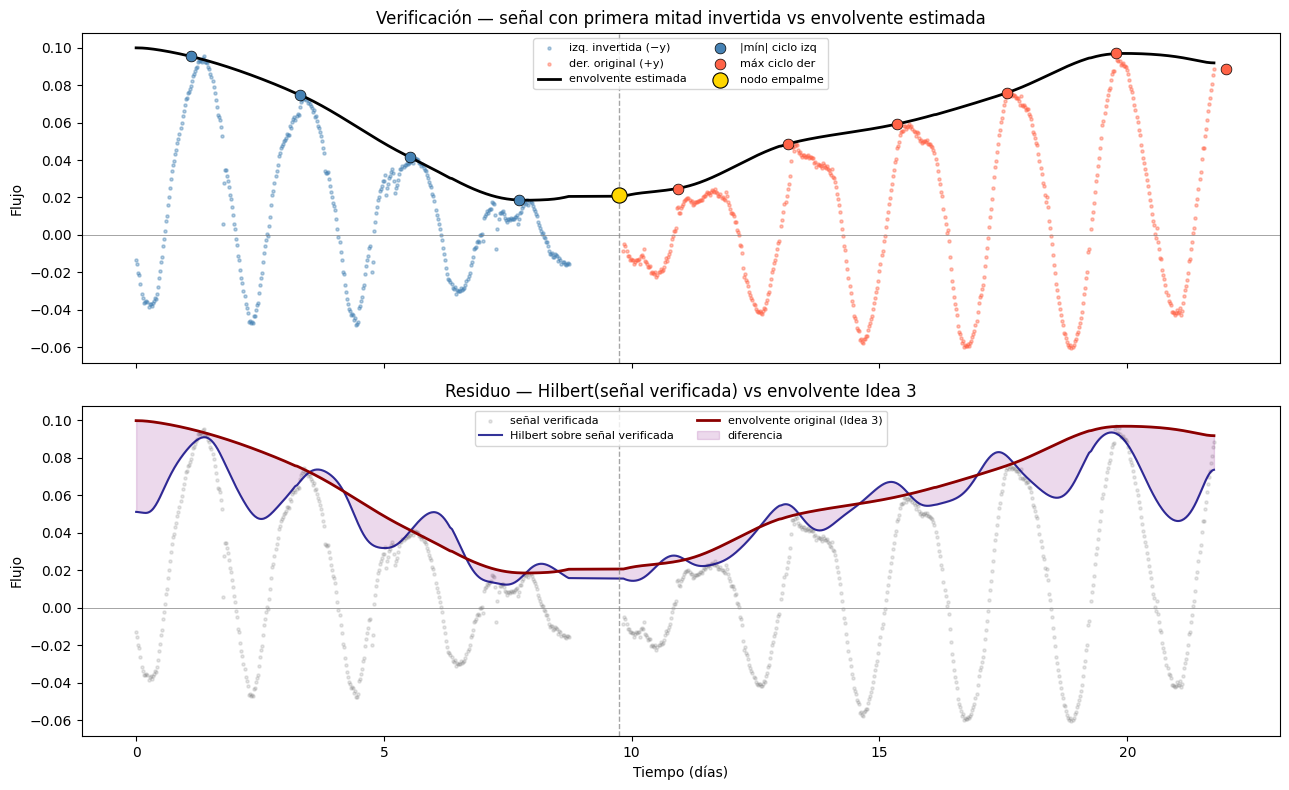

RMSE entre envolventes: 0.0175
  (si < 0.01 el ajuste es consistente con la verificación)


In [18]:
# ══════════════════════════════════════════════════════════
# VERIFICACIÓN: invertir la primera mitad y ver si los
# máximos resultantes coinciden con la envolvente estimada
# ══════════════════════════════════════════════════════════

T_VER = 9.75  # usar el mismo cruce visual

mask_iz = t < T_VER
mask_de = t >= T_VER

# Señal verificada: izquierda negada, derecha igual
y_ver = y.copy()
y_ver[mask_iz] = -y[mask_iz]

# ── figura de verificación ──
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel superior: superponer señal verificada con la envolvente
ax = axes[0]
ax.scatter(t[mask_iz], y_ver[mask_iz], s=5, alpha=0.4,
           color="steelblue", label="izq. invertida (−y)")
ax.scatter(t[mask_de], y_ver[mask_de], s=5, alpha=0.4,
           color="tomato",    label="der. original (+y)")

# Envolvente estimada por ciclos (env3_suave del paso anterior)
ax.plot(t, env3_suave, color="k", lw=2, label="envolvente estimada")

# Nodos que usamos para construirla
ax.scatter(t_iz_c, amp_iz_c, s=60, color="steelblue",
           zorder=5, edgecolors="k", lw=0.5, label="|mín| ciclo izq")
ax.scatter(t_de_c, amp_de_c, s=60, color="tomato",
           zorder=5, edgecolors="k", lw=0.5, label="máx ciclo der")
ax.scatter([T_VER], [val_cruce], s=120, color="gold",
           zorder=6, edgecolors="k", lw=0.8, label="nodo empalme")

ax.axvline(T_VER, color="gray", lw=1, ls="--", alpha=0.7)
ax.axhline(0,     color="gray", lw=0.5)
ax.set_title("Verificación — señal con primera mitad invertida vs envolvente estimada")
ax.legend(fontsize=8, ncol=2)
ax.set_ylabel("Flujo")

# Panel inferior: residuo — ¿cuánto se separan los máximos de la envolvente?
# Calculamos la envolvente de la señal verificada (Hilbert) para comparar
env_ver = gaussian_filter1d(np.abs(hilbert(y_ver)), sigma=10)

ax = axes[1]
ax.scatter(t, y_ver, s=5, alpha=0.2, color="gray", label="señal verificada")
ax.plot(t,  env_ver,    color="navy",    lw=1.5, alpha=0.8, label="Hilbert sobre señal verificada")
ax.plot(t,  env3_suave, color="darkred", lw=2,   label="envolvente original (Idea 3)")
ax.fill_between(t,
                env_ver, env3_suave,
                alpha=0.15, color="purple",
                label="diferencia")

ax.axvline(T_VER, color="gray", lw=1, ls="--", alpha=0.7)
ax.axhline(0,     color="gray", lw=0.5)
ax.set_title("Residuo — Hilbert(señal verificada) vs envolvente Idea 3")
ax.legend(fontsize=8, ncol=2)
ax.set_xlabel("Tiempo (días)")
ax.set_ylabel("Flujo")

plt.tight_layout()
plt.show()

# ── diagnóstico numérico ──
rmse_ver = np.sqrt(np.mean((env_ver - env3_suave)**2))
print(f"RMSE entre envolventes: {rmse_ver:.4f}")
print(f"  (si < 0.01 el ajuste es consistente con la verificación)")

Honestamente esta solución ya me gusta mucho, pero el rmse dice nein

Ciclos detectados: 10
Asimetría por ciclo (max-|min|)/(max+|min|):
  t= 1.10d  asim=-0.425  ↓mín
  t= 3.31d  asim=-0.227  ↓mín
  t= 5.52d  asim=+0.071  ↑máx
  t= 7.73d  asim=+0.187  ↑máx
  t= 9.94d  asim=-0.155  ↓mín
  t=12.15d  asim=+0.057  ↑máx
  t=14.36d  asim=-0.019  ↓mín
  t=16.57d  asim=+0.117  ↑máx
  t=18.78d  asim=+0.231  ↑máx
  t=20.99d  asim=+0.366  ↑máx

[Idea 4] P_env = 20.37 días
RMSE verificación: 0.0120


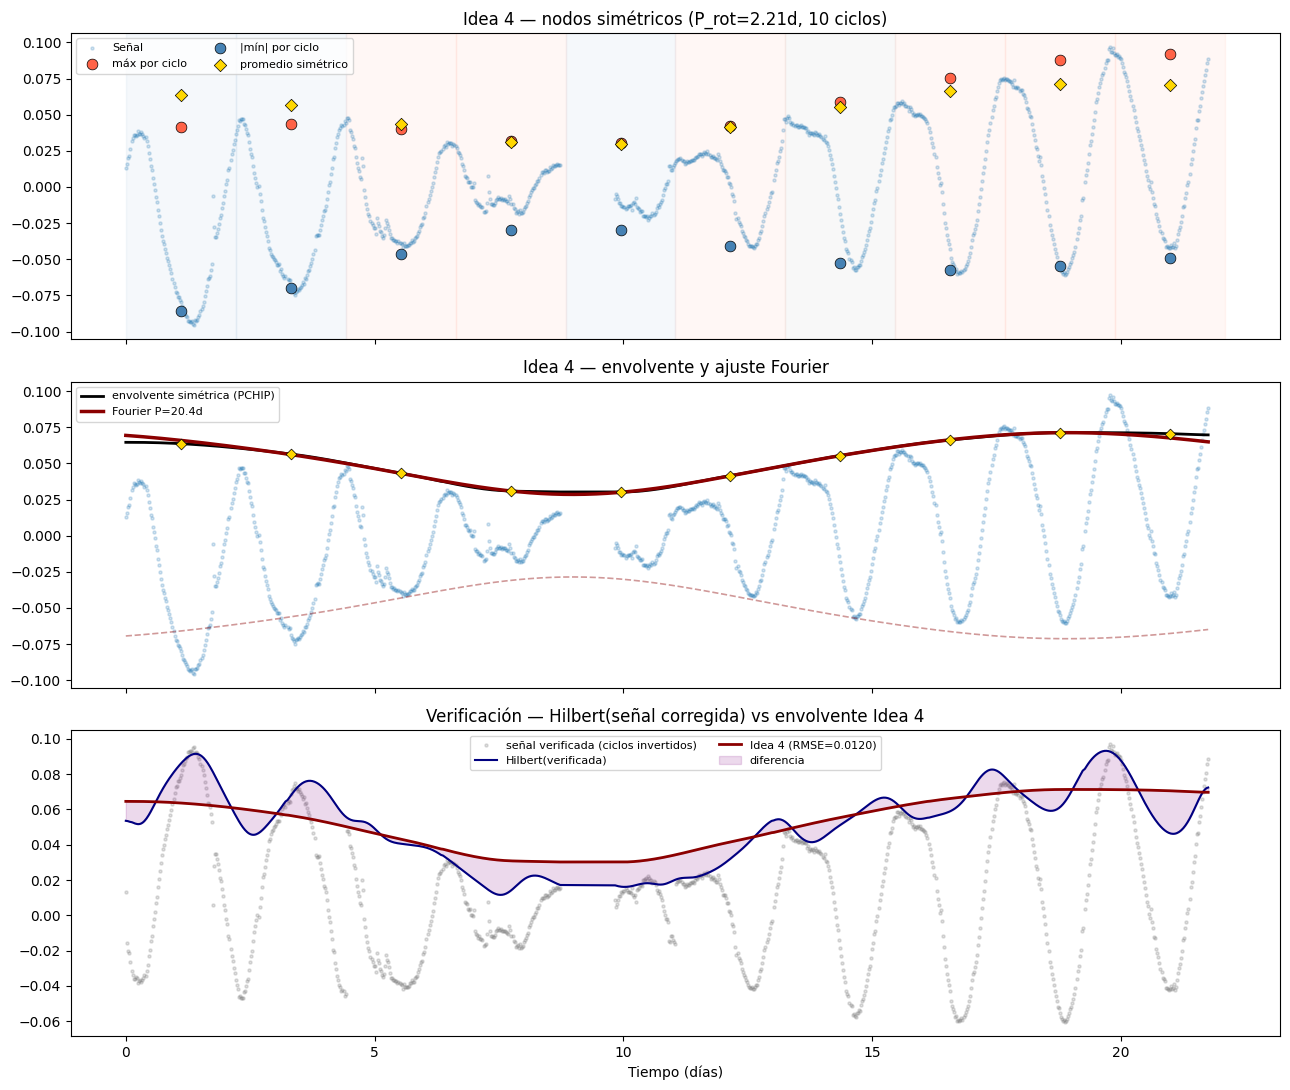

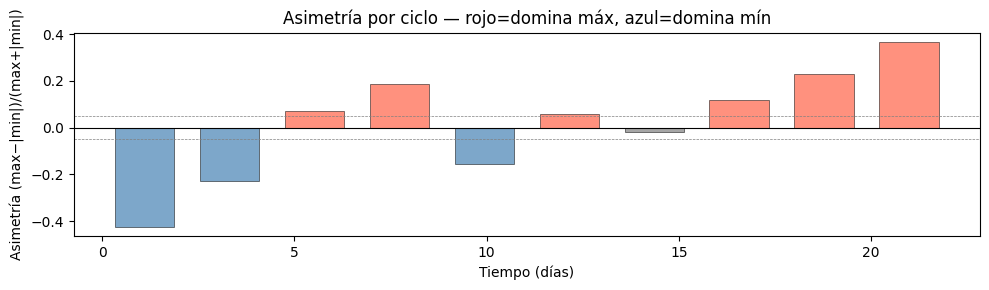

In [19]:
# ══════════════════════════════════════════════════════════
# IDEA 4 — envolvente simétrica por ciclo (max + |min|)/2
# Sin T_CRUCE, sin separación de mitades
# ══════════════════════════════════════════════════════════

def envolvente_simetrica(t, y, P, sigma_ciclos=1.5):
    """
    Por cada ventana de un ciclo de rotación calcula:
      - max(y)     → cima del ciclo
      - |min(y)|   → valle del ciclo
      - promedio de ambos → amplitud simétrica estimada
      - asimetría  → (max - |min|) / (max + |min|), útil para diagnóstico
    """
    t0, t1   = t.min(), t.max()
    bordes   = np.arange(t0, t1 + P, P)
    t_cent, amp_max, amp_min, asim = [], [], [], []

    for i in range(len(bordes) - 1):
        mask = (t >= bordes[i]) & (t < bordes[i+1])
        if mask.sum() < 3:
            continue
        yi = y[mask]
        vmax =  np.max(yi)
        vmin = np.abs(np.min(yi))
        t_cent.append(0.5 * (bordes[i] + bordes[i+1]))
        amp_max.append(vmax)
        amp_min.append(vmin)
        asim.append((vmax - vmin) / (vmax + vmin + 1e-10))

    t_cent  = np.array(t_cent)
    amp_max = np.array(amp_max)
    amp_min = np.array(amp_min)
    asim    = np.array(asim)

    # promedio simétrico
    amp_sim = 0.5 * (amp_max + amp_min)

    # suavizado en unidades de ciclos
    sig = sigma_ciclos
    if sig > 0 and len(amp_sim) > 2:
        amp_sim = gaussian_filter1d(amp_sim, sigma=sig)
        amp_max = gaussian_filter1d(amp_max, sigma=sig)
        amp_min = gaussian_filter1d(amp_min, sigma=sig)

    return t_cent, amp_sim, amp_max, amp_min, asim


t_c4, amp4, amp4_max, amp4_min, asim4 = envolvente_simetrica(
    t, y, P_rot, sigma_ciclos=1.0
)

print(f"Ciclos detectados: {len(t_c4)}")
print(f"Asimetría por ciclo (max-|min|)/(max+|min|):")
for tc, a in zip(t_c4, asim4):
    signo = "↑máx" if a > 0 else "↓mín"
    print(f"  t={tc:5.2f}d  asim={a:+.3f}  {signo}")

# ── PCHIP sobre la amplitud simétrica ──
interp4  = PchipInterpolator(t_c4, amp4)
env4     = np.clip(interp4(t), 0, None)   # forzar ≥ 0
env4_s   = gaussian_filter1d(env4, sigma=8)

# ── Lomb-Scargle ──
freq4, pow4 = LombScargle(t, env4_s).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)
P_env4 = 1 / freq4[np.argmax(pow4)]
print(f"\n[Idea 4] P_env = {P_env4:.2f} días")

# ── Fourier ──
fs4 = FourierSeries(n_terms=3, base_freq=1/P_env4)
fs4.fit(t, env4_s)
tt  = np.linspace(t.min(), t.max(), 3000)

# ── Verificación integrada: invertir donde asim < 0 ──
# (la señal "mira hacia abajo" cuando el mínimo domina)
y_ver4      = y.copy()
invertir    = t_c4[asim4 < -0.05]   # ciclos donde |mín| > máx
for tc in invertir:
    m = np.abs(t - tc) < P_rot/2
    y_ver4[m] = -y_ver4[m]
env_ver4 = gaussian_filter1d(np.abs(hilbert(y_ver4)), sigma=10)

rmse4 = np.sqrt(np.mean((env_ver4 - env4_s)**2))
print(f"RMSE verificación: {rmse4:.4f}")

# ── Figura ──
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax = axes[0]
ax.scatter(t, y, s=5, alpha=0.2, label="Señal")
ax.scatter(t_c4,  amp4_max, s=60, color="tomato",    zorder=5,
           edgecolors="k", lw=0.5, label="máx por ciclo")
ax.scatter(t_c4, -amp4_min, s=60, color="steelblue", zorder=5,
           edgecolors="k", lw=0.5, label="|mín| por ciclo")
ax.scatter(t_c4,  amp4,     s=40, color="gold",      zorder=6,
           edgecolors="k", lw=0.5, marker="D", label="promedio simétrico")
ax.set_title(f"Idea 4 — nodos simétricos (P_rot={P_rot:.2f}d, {len(t_c4)} ciclos)")
ax.legend(fontsize=8, ncol=2)

# colorear ciclos según asimetría
for i, (tc, a) in enumerate(zip(t_c4, asim4)):
    color = "tomato" if a > 0.05 else ("steelblue" if a < -0.05 else "gray")
    ax.axvspan(tc - P_rot/2, tc + P_rot/2,
               alpha=0.05, color=color, zorder=0)

ax = axes[1]
ax.scatter(t, y, s=5, alpha=0.2)
ax.plot(t,  env4_s,  color="k",       lw=2,   label="envolvente simétrica (PCHIP)")
ax.plot(tt, fs4(tt), color="darkred", lw=2.5, label=f"Fourier P={P_env4:.1f}d")
ax.plot(tt,-fs4(tt), color="darkred", lw=1.2, ls="--", alpha=0.4)
ax.scatter(t_c4, amp4, s=30, color="gold", zorder=5,
           edgecolors="k", lw=0.5, marker="D")
ax.set_title("Idea 4 — envolvente y ajuste Fourier")
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(t, y_ver4, s=5, alpha=0.25, color="gray", label="señal verificada (ciclos invertidos)")
ax.plot(t,  env_ver4, color="navy",    lw=1.5, label="Hilbert(verificada)")
ax.plot(t,  env4_s,   color="darkred", lw=2,   label=f"Idea 4 (RMSE={rmse4:.4f})")
ax.fill_between(t, env_ver4, env4_s, alpha=0.15, color="purple", label="diferencia")
ax.set_title("Verificación — Hilbert(señal corregida) vs envolvente Idea 4")
ax.set_xlabel("Tiempo (días)")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# ── asimetría por ciclo — útil para confirmar dónde está el cruce ──
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(t_c4, asim4, width=P_rot*0.7,
       color=["tomato" if a > 0.05 else ("steelblue" if a < -0.05 else "gray")
              for a in asim4],
       alpha=0.7, edgecolor="k", lw=0.5)
ax.axhline(0, color="k", lw=0.8)
ax.axhline( 0.05, color="gray", lw=0.5, ls="--")
ax.axhline(-0.05, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Tiempo (días)")
ax.set_ylabel("Asimetría (max−|min|)/(max+|min|)")
ax.set_title("Asimetría por ciclo — rojo=domina máx, azul=domina mín")
plt.tight_layout()
plt.show()

In [20]:
# ── duración total observada ──
T_obs = t.max() - t.min()

print(f"Inicio: {t.min():.3f} d")
print(f"Fin:    {t.max():.3f} d")
print(f"Duración total: {T_obs:.3f} días")

# comparar contra el período de envolvente
if "P_env4" in globals():
    N_env = T_obs / P_env4
    print(f"Ciclos de envolvente observados: {N_env:.2f}")

Inicio: 0.000 d
Fin:    21.750 d
Duración total: 21.750 días
Ciclos de envolvente observados: 1.07
